In [1]:
import torch
import pandas as pd
import numpy as np

In [2]:
import sys
import os
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))

from akita_model.model import SeqNN

In [3]:
from pyfaidx import Fasta

In [4]:
genome = Fasta("/project2/fudenber_735/genomes/mm10/mm10.fa")

In [5]:
# β-globin LCR coordinates (mm10)
LCR_CHR = "chr7"
LCR_START = 103851395
LCR_END = 103883181
LCR_CENTER = (LCR_START + LCR_END) // 2

# Akita parameters
SEQUENCE_LENGTH = 640 * 2048  # 1,310,720 bp
BIN_SIZE = 2048

In [6]:
# Calculate extraction window (centered on LCR)
half_length = SEQUENCE_LENGTH // 2
extract_start = LCR_CENTER - half_length
extract_end = LCR_CENTER + half_length

In [7]:
seq = genome[LCR_CHR][extract_start:extract_end].seq

In [10]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [11]:
seq_encoded = np.zeros((len(seq), 4), dtype=np.float32)
mapping = {'A': 0, 'C': 1, 'G': 2, 'T': 3}

for i, nuc in enumerate(seq):
    if nuc in mapping:
        seq_encoded[i, mapping[nuc]] = 1.0
    else:  # Handle N or ambiguous bases
        seq_encoded[i, :] = 0.25

# Convert to PyTorch tensor: (batch=1, channels=4, length)
seq_tensor = torch.from_numpy(seq_encoded).unsqueeze(0).permute(0, 2, 1)
seq_tensor = seq_tensor.to(device)

print(f"Input tensor shape: {seq_tensor.shape}")

Input tensor shape: torch.Size([1, 4, 1310720])


In [12]:
model = SeqNN()
model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/models/finetuned/mouse/Hsieh2019_mESC/checkpoints/Akita_v2_mouse_Hsieh2019_mESC_model0_finetuned.pth", map_location=device))
model.eval()

SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 128, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
    (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size=2, stride=2, paddi

In [14]:
with torch.no_grad():
    pred_seqnn = model(seq_tensor.to(device))

/home1/smaruj/miniconda3/envs/pytorch_hic/lib/python3.10/site-packages/torch/nn/modules/conv.py:306: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:84.)
  return F.conv1d(input, weight, bias, self.stride,


In [15]:
# Helper function to set diagonal elements to a specific value
def set_diag(matrix, value, k):
    # Explicitly set the diagonal to 'value' (in this case, np.nan) for each k
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value

def from_upper_triu(vector_repr, matrix_len, num_diags):
    # Ensure vector_repr is a NumPy array (if it's a PyTorch tensor, convert it)
    if isinstance(vector_repr, torch.Tensor):
        vector_repr = vector_repr.detach().flatten().cpu().numpy()  # Flatten and convert to NumPy array

    # Initialize a zero matrix of shape (matrix_len, matrix_len)
    z = np.zeros((matrix_len, matrix_len))

    # Get the indices for the upper triangular matrix
    triu_tup = np.triu_indices(matrix_len, num_diags)

    # Assign the values from the vector_repr to the upper triangular part of the matrix
    z[triu_tup] = vector_repr

    # Set the diagonals specified by num_diags to np.nan
    for i in range(-num_diags + 1, num_diags):
        set_diag(z, np.nan, i)

    # Ensure the matrix is symmetric
    return z + z.T

In [16]:
import matplotlib.pyplot as plt

<Figure size 800x800 with 0 Axes>

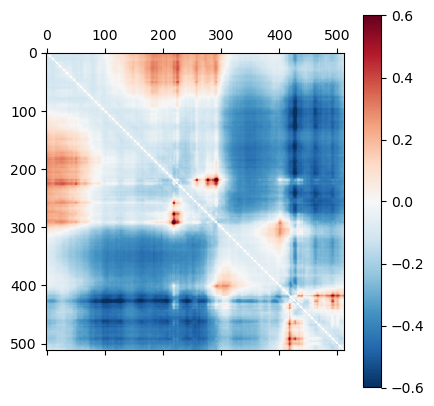

In [20]:
plt.figure(figsize=(8, 8))
matrix = from_upper_triu(pred_seqnn, matrix_len=512, num_diags=2)
plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
plt.colorbar()
plt.show()

In [21]:
center = 512 // 2          # 256
half_width = 15 // 2       # 7

start = center - half_width
end = center + half_width + 1  # +1 to make it 15 bins inclusive

<Figure size 800x800 with 0 Axes>

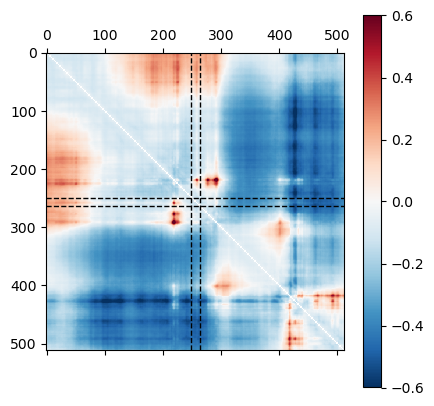

In [24]:
plt.figure(figsize=(8, 8))

matrix = from_upper_triu(pred_seqnn, matrix_len=512, num_diags=2)
plt.matshow(matrix.astype(np.float16),
            cmap='RdBu_r',
            vmin=-0.6,
            vmax=0.6)

# Central region bounds
center = 512 // 2
half_width = 15 // 2
start = center - half_width
end = center + half_width + 1

# Vertical dashed lines
plt.axvline(start, linestyle='--', linewidth=1, c="black")
plt.axvline(end, linestyle='--', linewidth=1, c="black")

# Horizontal dashed lines
plt.axhline(start, linestyle='--', linewidth=1, c="black")
plt.axhline(end, linestyle='--', linewidth=1, c="black")

plt.colorbar()
plt.show()

In [32]:
import cooler
from astropy.convolution import Gaussian2DKernel, convolve
from cooltools.lib.numutils import (
    adaptive_coarsegrain,
    interp_nan,
    observed_over_expected,
    set_diag,
)
from scipy.stats import pearsonr, spearmanr

In [33]:
COOL_FILE="/project2/fudenber_735/GEO/Hsieh2019/4DN/mESC_mm10_4DNFILZ1CPT8.mapq_30.2048.cool"

In [34]:
GAPS_FILE="/project2/fudenber_735/backup/DNN_HiC/data_mm10/mm10.blacklist.rep.bed"

In [40]:
import re

In [41]:
def extract_coordinates_from_mseq(mseq_str):
    """
    Parse genomic coordinates from string format.

    Args:
        mseq_str (str): Genomic region in format "chr:start-end"
                       Example: "chr1:1000000-2000000"

    Returns:
        tuple: (chrom, start, end)

    Raises:
        ValueError: If format is invalid
    """
    match = re.match(r"(?P<chrom>\w+):(?P<start>\d+)-(?P<end>\d+)", mseq_str)

    if not match:
        raise ValueError(f"Invalid coordinate format: {mseq_str}. Expected format: chr:start-end")

    chrom = match.group("chrom")
    start = int(match.group("start"))
    end = int(match.group("end"))

    return chrom, start, end

In [36]:
def process_hic_matrix(
    genome_hic_cool,
    mseq_str,
    diagonal_offset=2,
    padding=64,
    kernel_stddev=1,
    bin_size=2048,
    gaps_df=None,
):
    """
    Process a Hi-C contact matrix for a given genomic region.

    Processing steps:
        1. Load balanced matrix from cooler file
        2. Mask NaN rows/columns (low coverage regions)
        3. Mask gap regions (optional)
        4. Clip diagonal and extreme values
        5. Adaptive coarsegraining based on raw counts
        6. Calculate observed/expected and log transform
        7. Apply padding and interpolate remaining NaNs
        8. Gaussian smoothing

    Args:
        genome_hic_cool (cooler.Cooler): Cooler object for Hi-C data
        mseq_str (str): Genomic region string "chr:start-end"
        diagonal_offset (int): Number of diagonals to mask. Default: 2
        padding (int): Number of bins to crop from edges. Default: 64
        kernel_stddev (float): Std dev for Gaussian smoothing. Default: 1
        bin_size (int): Bin size in base pairs. Default: 2048
        gaps_df (pd.DataFrame): DataFrame with gap regions (chr, start, end).
                               Default: None

    Returns:
        np.ndarray: Processed Hi-C matrix (after padding removal)

    Note:
        Skips regions where >50% of bins are filtered (low quality data)
    """
    # Load balanced Hi-C matrix
    seq_hic_raw = genome_hic_cool.matrix(balance=True).fetch(mseq_str)
    chrom, start, end = extract_coordinates_from_mseq(mseq_str)

    # Identify NaN bins (low coverage)
    seq_hic_nan = np.isnan(seq_hic_raw)
    num_filtered_bins = np.sum(np.sum(seq_hic_nan, axis=0) == len(seq_hic_nan))

    # Quality check: skip if too many bins filtered
    if num_filtered_bins > (0.5 * len(seq_hic_nan)):
        print(
            f"Skipping {mseq_str}: >50% bins filtered ({num_filtered_bins}/{len(seq_hic_nan)})"
        )
        raise ValueError("Too many filtered bins")

    # Create masks for NaN rows and columns
    row_nan_mask = np.all(seq_hic_nan, axis=1)
    col_nan_mask = np.all(seq_hic_nan, axis=0)

    # Apply NaN masks
    seq_hic_raw[row_nan_mask, :] = np.nan
    seq_hic_raw[:, col_nan_mask] = np.nan

    # Mask gap regions if provided
    if gaps_df is not None:
        gaps_chr = gaps_df[gaps_df["chr"] == chrom]

        for _, gap in gaps_chr.iterrows():
            gap_start = gap["start"]
            gap_end = gap["end"]

            # Check for overlap with current region
            if (gap_start < end) and (gap_end > start):
                # Convert genomic coordinates to matrix indices
                gap_start_idx = max(gap_start - start, 0) // bin_size
                gap_end_idx = (
                    min(
                        gap_end - start,
                        seq_hic_raw.shape[0] * bin_size,
                        seq_hic_raw.shape[0] * bin_size,
                    )
                    // bin_size
                )

                # Update masks for gap regions
                row_nan_mask[gap_start_idx:gap_end_idx] = True
                col_nan_mask[gap_start_idx:gap_end_idx] = True

        # Apply updated masks
        seq_hic_raw[row_nan_mask, :] = np.nan
        seq_hic_raw[:, col_nan_mask] = np.nan

        print(f"Gap-masked rows: {np.sum(row_nan_mask)}")

    # Clip diagonal values and extreme outliers
    clipval = np.nanmedian(np.diag(seq_hic_raw, diagonal_offset))
    for i in range(-diagonal_offset + 1, diagonal_offset):
        set_diag(seq_hic_raw, clipval, i)

    seq_hic_raw = np.clip(seq_hic_raw, 0, clipval)
    seq_hic_raw[seq_hic_nan] = np.nan

    # Adaptive coarsegraining based on raw counts
    seq_hic_smoothed = adaptive_coarsegrain(
        seq_hic_raw, genome_hic_cool.matrix(balance=False).fetch(mseq_str), cutoff=2, max_levels=8
    )

    seq_hic_nan = np.isnan(seq_hic_smoothed)

    # Calculate observed/expected and log transform
    seq_hic_obsexp = observed_over_expected(seq_hic_smoothed, ~seq_hic_nan)[0]
    log_hic_obsexp = np.log(seq_hic_obsexp)

    # Apply padding (remove edge artifacts)
    if padding > 0:
        log_hic_obsexp = log_hic_obsexp[padding:-padding, padding:-padding]
        row_nan_mask = row_nan_mask[padding:-padding]
        col_nan_mask = col_nan_mask[padding:-padding]

    # Interpolate remaining NaNs
    log_hic_obsexp = interp_nan(log_hic_obsexp)

    # Zero out near-diagonal elements
    for i in range(-diagonal_offset + 1, diagonal_offset):
        set_diag(log_hic_obsexp, 0, i)

    # Apply Gaussian smoothing
    kernel = Gaussian2DKernel(x_stddev=kernel_stddev)
    seq_hic = convolve(log_hic_obsexp, kernel)

    return seq_hic


In [37]:
def upper_triangular_to_vector(matrix, dim=512, diag_offset=2):
    """
    Extract upper triangular portion of matrix, skipping near-diagonal.

    Args:
        matrix (np.ndarray): Square contact matrix
        dim (int): Matrix dimension (should match matrix.shape[0]). Default: 512
        diag_offset (int): Number of diagonals to skip. Default: 2

    Returns:
        np.ndarray: 1D vector of upper triangular elements

    Note:
        The first diag_offset diagonals are excluded as they often contain
        artifacts from Hi-C data processing.
    """
    upper_tri_indices = np.triu_indices(dim, k=diag_offset)
    upper_tri_vector = matrix[upper_tri_indices]

    return upper_tri_vector

In [38]:
genome_hic_cool = cooler.Cooler(COOL_FILE)

In [39]:
gaps_df = pd.read_csv(GAPS_FILE, sep="\t", header=None, names=["chr", "start", "end"])

In [44]:
mseq_str=f"{LCR_CHR}:{extract_start}-{extract_end}"

In [46]:
hic_matrix = process_hic_matrix(genome_hic_cool, mseq_str, bin_size=2048, gaps_df=gaps_df)

Gap-masked rows: 52


/home1/smaruj/miniconda3/envs/pytorch_hic/lib/python3.10/site-packages/cooltools/lib/numutils.py:1376: RuntimeWarning: invalid value encountered in divide
  val_cur = ar_cur / armask_cur


<Figure size 800x800 with 0 Axes>

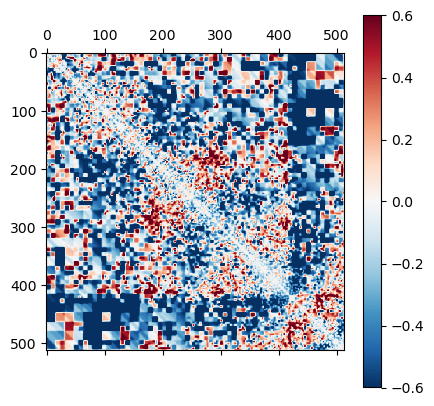

In [47]:
plt.figure(figsize=(8, 8))
plt.matshow(hic_matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
plt.colorbar()
plt.show()

In [48]:
vector_hic = upper_triangular_to_vector(hic_matrix)

In [51]:
from scipy.stats import pearsonr

In [52]:
# Convert torch tensor → numpy vector
pred_vec = pred_seqnn.squeeze().detach().cpu().numpy()

In [53]:
# Sanity check
assert pred_vec.shape == vector_hic.shape

# Pearson correlation
r, p = pearsonr(vector_hic, pred_vec)

print(f"Pearson R: {r:.4f}, p-value: {p:.2e}")

Pearson R: 0.2245, p-value: 0.00e+00
